In [68]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")
%matplotlib inline

from google.colab import files
uploaded = files.upload()



Saving titanic-parquet.csv to titanic-parquet.csv


In [77]:
df = pd.read_csv('titanic-parquet.csv')

# Basic cleaning
df = df.drop(columns=['Cabin', 'Ticket', 'Name'], errors='ignore')
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])
df['Age'] = pd.to_numeric(df['Age'], errors='coerce')
df['Age'] = df['Age'].fillna(df['Age'].median())
df = df.drop_duplicates()
df['Sex'] = df['Sex'].str.lower()

In [78]:
# Rename columns to lowercase, underscore format
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')

In [79]:
# Add family size and alone features
df['family_size'] = df['sibsp'] + df['parch']
df['is_alone'] = (df['family_size'] == 0).astype(int)

In [80]:
# Map categorical columns
df['sex'] = df['sex'].map({'male': 0, 'female': 1})
df['embarked'] = df['embarked'].map({'s': 0, 'c': 1, 'q': 2})
df['pclass'] = df['pclass'].astype('int')

In [81]:
# Optionally create age and fare groups
df['age_group'] = pd.cut(df['age'], bins=[0, 12, 18, 35, 60, 100], labels=[0,1,2,3,4])
df['fare_group'] = pd.qcut(df['fare'], 4, labels=False)

In [82]:
# Final feature list
features = ['pclass', 'sex', 'age_group', 'fare_group', 'embarked', 'family_size', 'is_alone']
X = df[features].astype(float)
y = df['survived']

In [83]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)


In [84]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

model = RandomForestClassifier(n_estimators=200, max_depth=8, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print(f"Accuracy: {accuracy_score(y_test, y_pred):.2%}")

print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))


Accuracy: 81.56%
Confusion Matrix:
 [[94 11]
 [22 52]]
Classification Report:
               precision    recall  f1-score   support

           0       0.81      0.90      0.85       105
           1       0.83      0.70      0.76        74

    accuracy                           0.82       179
   macro avg       0.82      0.80      0.80       179
weighted avg       0.82      0.82      0.81       179



In [85]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [6, 8, 10],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

grid = GridSearchCV(RandomForestClassifier(random_state=42), param_grid, cv=5, scoring='accuracy')
grid.fit(X_train, y_train)

print("Best Params:", grid.best_params_)

best_model = grid.best_estimator_
y_pred = best_model.predict(X_test)
print(f"Tuned Accuracy: {accuracy_score(y_test, y_pred):.2%}")


Best Params: {'max_depth': 6, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 100}
Tuned Accuracy: 81.56%


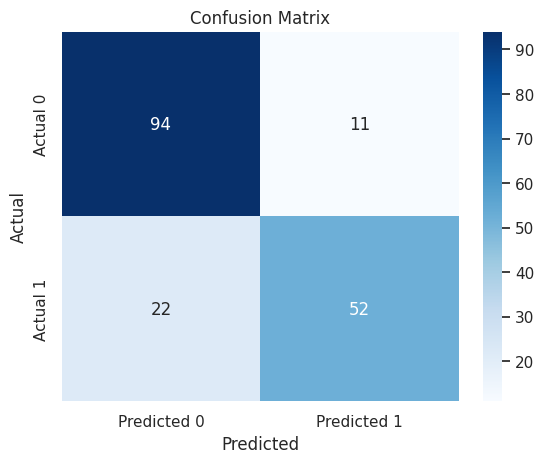

In [86]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Predicted 0', 'Predicted 1'], yticklabels=['Actual 0', 'Actual 1'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()
